# Planning optimization project

You are a freelancer network optimization engineer. A big telco wants to install coverage in a public area and it is paying you to optimize the deployment.

These are the goals:
- Cover all test points in the area
- Minimize the network cost
- Guarantee a minimum peak bitrate of 7 Mbps at every test point

The telco can buy macro base stations (high cost, high power) and micro base stations (low cost, low power).
It is easier for the procurement department of the big telco to buy and use only one BS type, either micro or marco. Thus, they are asking you to find out which type is better in terms of cost when only one BS type is installed.

But if the cost reduction of installing both types in an optimized way in the planning are is good, they can consider it. So they also ask you to see what happens in this case, and how much is the cost reduction (if there is any).

To recap, here is what the big telco asks you:
1. Given the geographic area, plan a wireless network deployments with the aforementioned goals.
2. Find out if it is better to use macro or micro base stations
3. Find what would be the cost reduction if a mix of macro and micro base stations would be installed

Model this planning objectives and constraints as a MILP formulation, and solve the given planning instance to the optimum.


### Deliverables
For this project, you will hand in:
- This colab notebook with your code
- A 2 page PDF where you detail the mathematical formulation, the results of the planning and the answer to the big telco questions.

In the report, please explain every set, parameter, variable and constraint of your formulation. Use plots to show the network layout and compute the final network cost in all the cases.

### Hints

> **How can I model the throuput?**

In this case, the Shannon capacity formula is good enough. So assuming we know the bandwidth (BW) and the SNR of a connection, we can compute the throughput with this formula:

$ Thr = BW * \log_2(1+SNR) $

Note that in this formula the SNR is not in dB. We assume a BW of 20 MHz, and a noise power of -95 dBm. You can use the received power at each TP to compute the SNR with every CS and then the throughput with every CS. This can be a parameter...

> **How can I model the different types of base stations?**

When only one type is installed, there is no need to modify the model. In the case where 2 types of BS can be installed in a CS, you will probably need to modify a few parameters and variables. There are few ways to do this. An easy one is to introduce the different types as an additional index for variables and parameters. For instance a variable $v_a$ becomes $v_{a,b}$, where $b$ is now an index accounting for the type of BS.

> **How can I minimize the cost?**

This is simple, what was a constraint before becomes a minimization now.

**Use the data computed in this colab as a starting points, a TP can be considered as covered if the received power of the associated BS is higher than the sensitivity $\gamma$**



In [ ]:
import matplotlib.pyplot as plt
import numpy as np


%pip install -q amplpy

from amplpy import AMPL, ampl_notebook

ampl = ampl_notebook(
    modules=["highs"],
    license_uuid="default",
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 51.5 MB/s eta 0:00:00
Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).


In [ ]:
# Planning parameters

np.random.seed(0)  # Seed for reproducibility

area_width = 1500
area_height = 1500

num_cs = 50

num_tp = 100

p_t_macro = 40 # dBm
p_t_micro = 30 # dBm
g_t = 1
g_r = 1
gamma = -75 # dBm

f = 700 # MHz

h_b = 30
h_m = 1.3

noise_power = -95 # dBm
bw_macro = 20e6
bw_micro = 10e6

# we are using the Hokomura-Hata model
def pathloss_oh(h_b, h_m, f, d):
  c_h = 0.8 + (1.1*np.log10(f) - 0.7)*h_m - 1.56 * np.log10(f)
  l_p = 69.55 + 26.26 * np.log10(f) - 13.82*np.log10(h_b) - c_h + (44.9 - 6.55*np.log10(h_b))*np.log10(d)
  return l_p


# Generate uniform random values
cs_x_coords = np.random.uniform(0, area_width, num_cs)
cs_y_coords = np.random.uniform(0, area_height, num_cs)

installation_costs_macroBS = np.random.uniform(1, 5, num_cs)
installation_costs_microBS = np.random.uniform(1, 5, num_cs)/5

tp_x_coords = np.random.uniform(0, area_width, num_tp)
tp_y_coords = np.random.uniform(0, area_height, num_tp)

distances = np.arange(1, 11)
 # Compute path loss using Hata model
pathloss_values = [pathloss_oh(h_b, h_m, f, d) for d in distances]

p_r_macro = np.zeros((num_cs, num_tp))
for i in range(num_cs):
    for j in range(num_tp):
        d = np.sqrt((cs_x_coords[i] - tp_x_coords[j])**2 + (cs_y_coords[i] - tp_y_coords[j])**2) / 1000
        l_p = pathloss_oh(h_b, h_m, f, d)
        p_r_macro[i, j] = p_t_macro + g_t + g_r - l_p

p_r_micro = np.zeros((num_cs, num_tp))
for i in range(num_cs):
    for j in range(num_tp):
        d = np.sqrt((cs_x_coords[i] - tp_x_coords[j])**2 + (cs_y_coords[i] - tp_y_coords[j])**2) / 1000
        l_p = pathloss_oh(h_b, h_m, f, d)
        p_r_micro[i, j] = p_t_micro + g_t + g_r - l_p


In [ ]:
thr_min = 7e6  # 7 Mbps

In [ ]:
# Function to calculate SNR in linear scale
def calculate_snr_linear(p_r_dbm, noise_power_dbm):  # Function to compute linear SNR from dBm values
    p_r_linear = 10**(p_r_dbm / 10) # Convert received power from dBm to linear
    noise_power_linear = 10**(noise_power_dbm / 10) # Convert noise power from dBm to linear
    return p_r_linear / noise_power_linear

In [ ]:
# Function to calculate throughput using Shannon capacity
def calculate_throughput(bw, snr_linear):
    return bw * np.log2(1 + snr_linear)

In [ ]:
# Calculate throughput for macro and micro BS for all CS-TP pairs
throughput_macro = np.zeros((num_cs, num_tp))
throughput_micro = np.zeros((num_cs, num_tp))

In [ ]:
for i in range(num_cs):
    for j in range(num_tp):
        # Function to compute linear SNR from dBm values
        snr_macro_linear = calculate_snr_linear(p_r_macro[i, j], noise_power)
        throughput_macro[i, j] = calculate_throughput(bw_macro, snr_macro_linear)

        snr_micro_linear = calculate_snr_linear(p_r_micro[i, j], noise_power)
        throughput_micro[i, j] = calculate_throughput(bw_micro, snr_micro_linear)

In [ ]:
def run_scenario(scenario):
    """Run optimization for a specific scenario"""
    ampl = AMPL()

    # Define base model with parameters first
    ampl.eval("""
    reset;

    # Parameters (defined first to avoid reference errors)
    param gamma;
    param thr_min;  # Minimum throughput requirement (7 Mbps)

    # Sets
    set CS;
    set TP;
    """)

    # Set parameters that are used in all scenarios
    ampl.param['gamma'] = gamma
    ampl.param['thr_min'] = thr_min  # Minimum throughput requirement (7 Mbps)

    # Scenario-specific model components
    if scenario == "mixed":
        ampl.eval("""
        set BS_TYPE;

        param cost{CS, BS_TYPE};
        param throughput{CS, TP, BS_TYPE};
        param p_r{CS, TP, BS_TYPE};

        var x{CS, BS_TYPE} binary;
        var y{TP, CS, BS_TYPE} binary;

        minimize Total_Cost:
            sum{i in CS, t in BS_TYPE} cost[i,t] * x[i,t];

        subject to Coverage{j in TP}:
            sum{i in CS, t in BS_TYPE} y[j,i,t] = 1;

        subject to Service{j in TP, i in CS, t in BS_TYPE}:
            y[j,i,t] <= x[i,t];

        subject to Signal_Strength{j in TP, i in CS, t in BS_TYPE}:
            y[j,i,t] * p_r[i,j,t] >= y[j,i,t] * gamma;

        subject to Minimum_Throughput{j in TP, i in CS, t in BS_TYPE}:
            y[j,i,t] * throughput[i,j,t] >= y[j,i,t] * thr_min;  # Minimum throughput requirement (7 Mbps)
        """)
    else:
        bs_type = scenario
        ampl.eval(f"""
        param cost{{CS}};
        param throughput{{CS, TP}};
        param p_r{{CS, TP}};

        var x{{CS}} binary;
        var y{{TP, CS}} binary;

        minimize Total_Cost:
            sum{{i in CS}} cost[i] * x[i];

        subject to Coverage{{j in TP}}:
            sum{{i in CS}} y[j,i] = 1;

        subject to Service{{j in TP, i in CS}}:
            y[j,i] <= x[i];

        subject to Signal_Strength{{j in TP, i in CS}}:
            y[j,i] * p_r[i,j] >= y[j,i] * gamma;

        subject to Minimum_Throughput{{j in TP, i in CS}}:
            y[j,i] * throughput[i,j] >= y[j,i] * thr_min;  # Minimum throughput requirement (7 Mbps)
        """)

    # Set scenario-specific data
    ampl.set['CS'] = list(range(num_cs))
    ampl.set['TP'] = list(range(num_tp))

    if scenario == "mixed":
        ampl.set['BS_TYPE'] = ['macro', 'micro']

        cost_data = {(i, 'macro'): installation_costs_macroBS[i] for i in range(num_cs)}
        cost_data.update({(i, 'micro'): installation_costs_microBS[i] for i in range(num_cs)})
        ampl.param['cost'] = cost_data

        throughput_data = {(i, j, 'macro'): throughput_macro[i,j] for i in range(num_cs) for j in range(num_tp)}
        throughput_data.update({(i, j, 'micro'): throughput_micro[i,j] for i in range(num_cs) for j in range(num_tp)})
        ampl.param['throughput'] = throughput_data

        p_r_data = {(i, j, 'macro'): p_r_macro[i,j] for i in range(num_cs) for j in range(num_tp)}
        p_r_data.update({(i, j, 'micro'): p_r_micro[i,j] for i in range(num_cs) for j in range(num_tp)})
        ampl.param['p_r'] = p_r_data
    else:
        if scenario == 'macro':
            ampl.param['cost'] = {i: installation_costs_macroBS[i] for i in range(num_cs)}
            ampl.param['throughput'] = {(i, j): throughput_macro[i,j] for i in range(num_cs) for j in range(num_tp)}
            ampl.param['p_r'] = {(i, j): p_r_macro[i,j] for i in range(num_cs) for j in range(num_tp)}
        else:
            ampl.param['cost'] = {i: installation_costs_microBS[i] for i in range(num_cs)}
            ampl.param['throughput'] = {(i, j): throughput_micro[i,j] for i in range(num_cs) for j in range(num_tp)}
            ampl.param['p_r'] = {(i, j): p_r_micro[i,j] for i in range(num_cs) for j in range(num_tp)}

    # Solve
    ampl.option['solver'] = 'highs'
    ampl.solve()

    return ampl

In [ ]:
def get_results(ampl, scenario):
    """Extract results from AMPL model"""
    total_cost = ampl.get_objective('Total_Cost').value()

    if scenario == "mixed":
        x_values = ampl.get_variable('x')
        macro_count = sum(1 for i in range(num_cs) if x_values.get((i, 'macro')).value() > 0.5)
        micro_count = sum(1 for i in range(num_cs) if x_values.get((i, 'micro')).value() > 0.5)
        return {
            'scenario': scenario,
            'total_cost': total_cost,
            'macro_count': macro_count,
            'micro_count': micro_count,
            'bs_count': macro_count + micro_count
        }
    else:
        x_values = ampl.get_variable('x')
        bs_count = sum(1 for i in range(num_cs) if x_values.get(i).value() > 0.5)
        return {
            'scenario': scenario,
            'total_cost': total_cost,
            'macro_count': bs_count if scenario == 'macro' else 0,
            'micro_count': bs_count if scenario == 'micro' else 0,
            'bs_count': bs_count
        }

In [ ]:
def get_results(ampl, scenario):
    """Extract results from AMPL model"""
    total_cost = ampl.get_objective('Total_Cost').value()

    if scenario == "mixed":
        x_values = ampl.get_variable('x')
        macro_count = sum(1 for i in range(num_cs) if x_values.get((i, 'macro')).value() > 0.5)
        micro_count = sum(1 for i in range(num_cs) if x_values.get((i, 'micro')).value() > 0.5)
        return {
            'scenario': scenario,
            'total_cost': total_cost,
            'macro_count': macro_count,
            'micro_count': micro_count,
            'bs_count': macro_count + micro_count
        }
    else:
        x_values = ampl.get_variable('x')
        bs_count = sum(1 for i in range(num_cs) if x_values.get(i).value() > 0.5)
        return {
            'scenario': scenario,
            'total_cost': total_cost,
            'macro_count': bs_count if scenario == 'macro' else 0,
            'micro_count': bs_count if scenario == 'micro' else 0,
            'bs_count': bs_count
        }

In [ ]:
def plot_deployment(ampl, scenario, ax):
    """Plot the deployment for a scenario"""
    ax.scatter(tp_x_coords, tp_y_coords, c='blue', alpha=0.3, label='Test Points', s=10)

    if scenario == "mixed":
        x_values = ampl.get_variable('x')
        for i in range(num_cs):
            for t in ['macro', 'micro']:
                if x_values.get((i, t)).value() > 0.5:
                    color = 'red' if t == 'macro' else 'green'
                    marker = 's' if t == 'macro' else '^'
                    ax.scatter(cs_x_coords[i], cs_y_coords[i], c=color, marker=marker,
                             s=100, label=f'{t} BS' if i == 0 else "")
    else:
        x_values = ampl.get_variable('x')
        for i in range(num_cs):
            if x_values.get(i).value() > 0.5:
                color = 'red' if scenario == 'macro' else 'green'
                marker = 's' if scenario == 'macro' else '^'
                ax.scatter(cs_x_coords[i], cs_y_coords[i], c=color, marker=marker,
                         s=100, label=f'{scenario} BS' if i == 0 else "")

    ax.set_title(f'{scenario.capitalize()} Deployment')
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.legend()
    ax.grid(True)

HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 7.991855599
1316 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 4.767364495
390 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 4.582439056
1921 simplex iterations
1 branching nodes


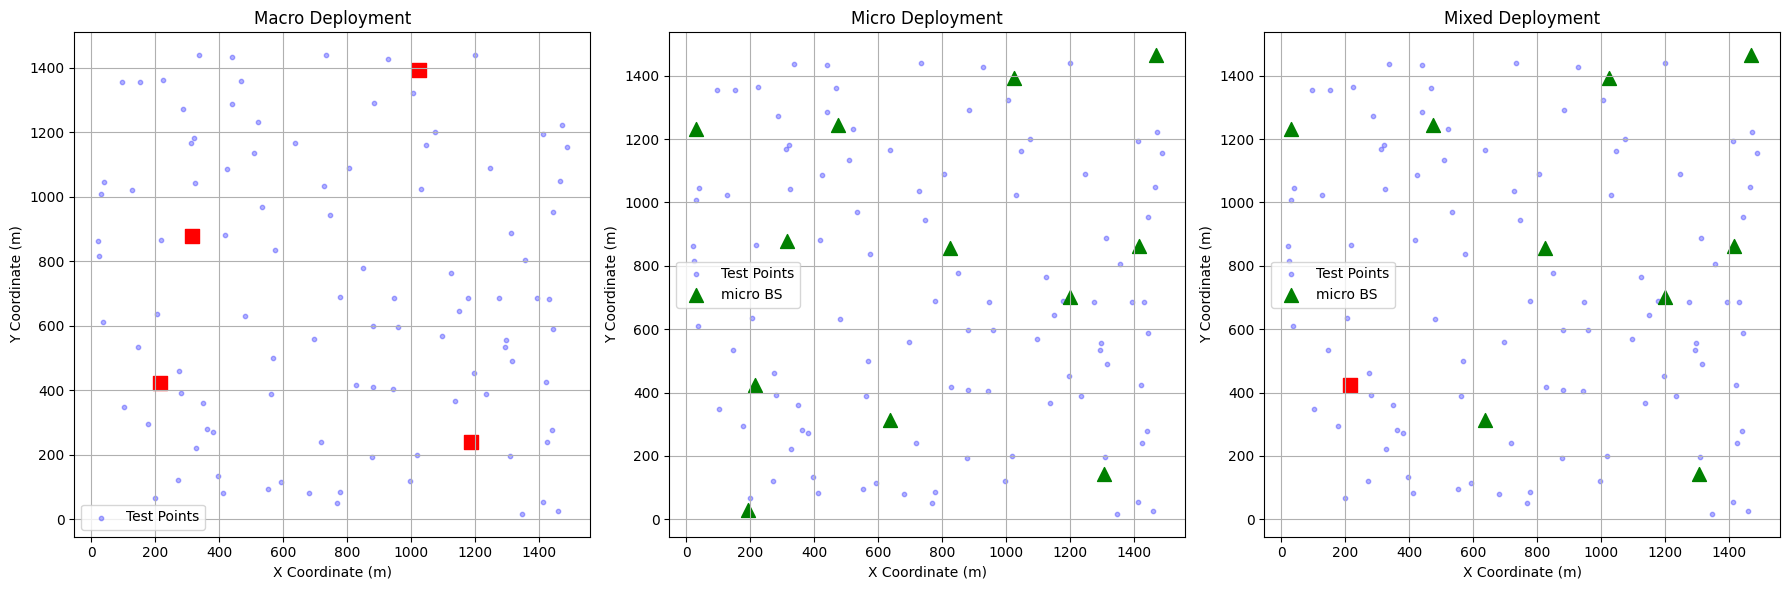


=== Scenario Comparison ===
Scenario   | Total Cost ($)  | Macro BS | Micro BS | Total BS
------------------------------------------------------------
macro      | 7.99            | 4        | 0        | 4       
micro      | 4.77            | 0        | 12       | 12      
mixed      | 4.58            | 1        | 9        | 10      

Optimal scenario is 'mixed' with total cost $4.58
Cost savings compared to:
- macro: 42.7% savings
- micro: 3.9% savings


In [ ]:
# Run all scenarios and collect results
results = []
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, scenario in enumerate(['macro', 'micro', 'mixed']):
    ampl = run_scenario(scenario)
    scenario_results = get_results(ampl, scenario)
    results.append(scenario_results)
    plot_deployment(ampl, scenario, axes[i])

plt.tight_layout()
plt.show()

# Print comparison table
print("\n=== Scenario Comparison ===")
print(f"{'Scenario':<10} | {'Total Cost ($)':<15} | {'Macro BS':<8} | {'Micro BS':<8} | {'Total BS':<8}")
print("-" * 60)
for res in results:
    print(f"{res['scenario']:<10} | {res['total_cost']:<15.2f} | {res['macro_count']:<8} | {res['micro_count']:<8} | {res['bs_count']:<8}")

# Determine optimal scenario
optimal = min(results, key=lambda x: x['total_cost'])
print(f"\nOptimal scenario is '{optimal['scenario']}' with total cost ${optimal['total_cost']:.2f}")
print(f"Cost savings compared to:")
for res in results:
    if res['scenario'] != optimal['scenario']:
        savings = ((res['total_cost'] - optimal['total_cost']) / res['total_cost']) * 100
        print(f"- {res['scenario']}: {savings:.1f}% savings")

In [ ]:
# Sensitivity Analysis: Vary gamma and thr_min
gamma_values = [-80, -75, -70]  # dBm
thr_min_values = [5e6, 7e6, 10e6]  # bps

sensitivity_results = []


In [ ]:
for g in gamma_values:
    for thr in thr_min_values:  # Minimum throughput requirement (7 Mbps)
        gamma = g
        thr_min = thr  # Minimum throughput requirement (7 Mbps)
        row = {'gamma': gamma, 'thr_min (Mbps)': thr / 1e6}  # Minimum throughput requirement (7 Mbps)

        for scenario in ['macro', 'micro', 'mixed']:
            ampl = run_scenario(scenario)
            result = get_results(ampl, scenario)
            row[f'{scenario}_cost'] = result['total_cost']
            row[f'{scenario}_bs'] = result['bs_count']

        sensitivity_results.append(row)


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 3.480939442
1931 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 1.89513659
732 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 1.89513659
2849 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 3.480939442
1931 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 1.89513659
732 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 1.89513659
2849 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 3.480939442
1931 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 1.89513659
732 simplex iterations
1 branching nodes
HiGHS 1.11.0: 

	
	line -1 offset -1
	presolve, constraint Signal_Strength[95,0]:
		all variables eliminated, but lower bound = 18.1223 > 0
	presolve, constraint Signal_Strength[86,0]:
		all variables eliminated, but lower bound = 17.8563 > 0
	presolve, constraint Signal_Strength[85,0]:
		all variables eliminated, but lower bound = 18.6625 > 0
	presolve, constraint Signal_Strength[76,0]:
		all variables eliminated, but lower bound = 16.4195 > 0
	presolve, constraint Signal_Strength[10,0]:
		all variables eliminated, but lower bound = 17.4573 > 0


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 10.88089389
1115 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 15.65949545
1071 simplex iterations
1 branching nodes


	
	line -1 offset -1
	presolve, constraint Signal_Strength[95,0]:
		all variables eliminated, but lower bound = 18.1223 > 0
	presolve, constraint Signal_Strength[86,0]:
		all variables eliminated, but lower bound = 17.8563 > 0
	presolve, constraint Signal_Strength[85,0]:
		all variables eliminated, but lower bound = 18.6625 > 0
	presolve, constraint Signal_Strength[76,0]:
		all variables eliminated, but lower bound = 16.4195 > 0
	presolve, constraint Signal_Strength[10,0]:
		all variables eliminated, but lower bound = 17.4573 > 0


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 10.88089389
1115 simplex iterations
1 branching nodes
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 15.65949545
1071 simplex iterations
1 branching nodes


	
	line -1 offset -1
	presolve, constraint Signal_Strength[95,0]:
		all variables eliminated, but lower bound = 18.1223 > 0
	presolve, constraint Signal_Strength[86,0]:
		all variables eliminated, but lower bound = 17.8563 > 0
	presolve, constraint Signal_Strength[85,0]:
		all variables eliminated, but lower bound = 18.6625 > 0
	presolve, constraint Signal_Strength[76,0]:
		all variables eliminated, but lower bound = 16.4195 > 0
	presolve, constraint Signal_Strength[10,0]:
		all variables eliminated, but lower bound = 17.4573 > 0


HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 10.88089389
1115 simplex iterations
1 branching nodes


In [ ]:
import pandas as pd
df_sens = pd.DataFrame(sensitivity_results)
print(df_sens.round(2))


   gamma  thr_min (Mbps)  macro_cost  macro_bs  micro_cost  micro_bs  \
0    -80             5.0        3.48         2        1.90         7   
1    -80             7.0        3.48         2        1.90         7   
2    -80            10.0        3.48         2        1.90         7   
3    -75             5.0        7.99         4        4.77        12   
4    -75             7.0        7.99         4        4.77        12   
5    -75            10.0        7.99         4        4.77        12   
6    -70             5.0       15.66         7        4.70         9   
7    -70             7.0       15.66         7        4.70         9   
8    -70            10.0       15.66         7        4.70         9   

   mixed_cost  mixed_bs  
0        1.90         7  
1        1.90         7  
2        1.90         7  
3        4.58        10  
4        4.58        10  
5        4.58        10  
6       10.88        12  
7       10.88        12  
8       10.88        12  
